# Mini-Project: Spam Mail Prediction
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

End-to-end text classification on SMS spam/ham using TF-IDF and Logistic Regression.

### Main goals:

- Apply this week's preprocessing checks (class balance, leakage) to text data.
- Convert raw text into numeric features using TF-IDF.
- Train and evaluate a Logistic Regression spam classifier.
- Test the model on hand-written example messages.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Load the Dataset

In [2]:
url = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/main/dataset/spam_mail_data.csv'

try:
    df = pd.read_csv(url)
except Exception as e:
    print(f'URL load failed ({e}), using local sample')
    sample_data = {
        'Category': ['ham','spam','ham','spam','ham','spam','ham','ham','spam','ham'] * 20,
        'Message': [
            'Hey, are we still meeting for lunch today?',
            'WINNER! You have been selected for a free cruise. Call now to claim!!!',
            'Can you send me the notes from yesterday\'s class?',
            'URGENT: Your account has been suspended. Click here to verify immediately.',
            'Mom said dinner is ready, come down',
            'Congratulations! You won a $1000 Walmart gift card. Reply YES to claim.',
            'Let\'s catch up this weekend, free on Saturday?',
            'I\'ll be there in 10 minutes, traffic is bad',
            'FREE entry in a weekly competition to win an iPhone. Text WIN to 80086',
            'See you at the library after class'
        ] * 20
    }
    df = pd.DataFrame(sample_data)

print(df.shape)
df.head()

(5572, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Class Balance

In [3]:
print(df['Category'].value_counts())
print(f'Spam rate: {(df["Category"]=="spam").mean()*100:.1f}%')

Category
ham     4825
spam     747
Name: count, dtype: int64
Spam rate: 13.4%


**Observation:**
Imbalanced in the same direction as the fraud example — spam is the minority class.

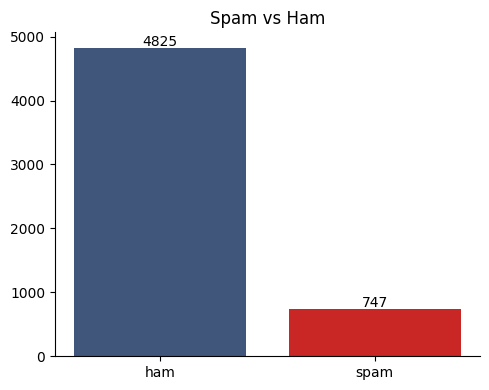

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['Category'].value_counts()
ax.bar(counts.index, counts.values, color=['#1F3864', '#C00000'], alpha=0.85)
for i, c in enumerate(counts.values):
    ax.text(i, c + 20, str(c), ha='center')
ax.set_title('Spam vs Ham')
plt.tight_layout()
plt.show()

## Message Length by Category

Category
ham      71.4
spam    138.0
Name: message_length, dtype: float64


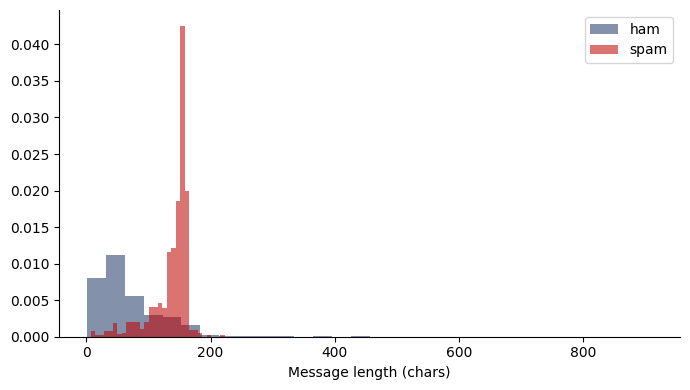

In [5]:
df['message_length'] = df['Message'].apply(len)
print(df.groupby('Category')['message_length'].mean().round(1))

fig, ax = plt.subplots(figsize=(7, 4))
for cat, color in [('ham', '#1F3864'), ('spam', '#C00000')]:
    ax.hist(df[df['Category']==cat]['message_length'], bins=30, alpha=0.55, color=color, label=cat, density=True)
ax.set_xlabel('Message length (chars)')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:**
Spam messages run longer on average. Spam tends to cram in a call-to-action, an offer, a link or number, and urgency language, which adds length compared to a short genuine text.

## Text Cleaning

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_message'] = df['Message'].apply(clean_text)

for i in [0, 1]:
    print('Original:', df['Message'].iloc[i])
    print('Cleaned :', df['cleaned_message'].iloc[i])
    print()

Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned : go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

Original: Ok lar... Joking wif u oni...
Cleaned : ok lar joking wif u oni



**Observation:**
Stripping non-letters also removes phone numbers and dollar amounts, which may be losing a real spam signal. Kept simple for this first pass.

## TF-IDF

In [7]:
X = df['cleaned_message']
y = df['Category'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3, stratify=y)

# fit on training data only - same leakage rule as the scaler notebook, applied to text
vectorizer = TfidfVectorizer(min_df=2, stop_words='english', lowercase=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'X_train_tfidf shape: {X_train_tfidf.shape}')

Vocabulary size: 3078
X_train_tfidf shape: (4457, 3078)


**Observation:**
TF-IDF produces a high-dimensional feature representation with one column per vocabulary term. Each message becomes a mostly sparse vector rather than a single numeric encoding.

In [8]:
feature_names = np.array(vectorizer.get_feature_names_out())
train_df = pd.DataFrame(X_train_tfidf.toarray(), columns=feature_names)
train_df['label'] = y_train.values

spam_means = train_df[train_df['label']==1].drop('label', axis=1).mean().sort_values(ascending=False)
ham_means  = train_df[train_df['label']==0].drop('label', axis=1).mean().sort_values(ascending=False)

print('Top spam words:', spam_means.head(10).index.tolist())
print('Top ham words: ', ham_means.head(10).index.tolist())

Top spam words: ['free', 'txt', 'stop', 'claim', 'mobile', 'text', 'prize', 'reply', 'www', 'ur']
Top ham words:  ['ok', 'll', 'gt', 'lt', 'come', 'like', 'just', 'good', 'got', 'know']


**Observation:**
Top spam words look promotional and urgent, top ham words look conversational, consistent with what spam messages typically look like.

## Training the Model

In [9]:
model = LogisticRegression(max_iter=1000).fit(X_train_tfidf, y_train)

train_preds = model.predict(X_train_tfidf)
test_preds  = model.predict(X_test_tfidf)

print('Train accuracy:', round(accuracy_score(y_train, train_preds), 4))
print()
print(f'Test accuracy:  {accuracy_score(y_test, test_preds):.4f}')
print(f'Precision:      {precision_score(y_test, test_preds):.4f}')
print(f'Recall:         {recall_score(y_test, test_preds):.4f}')
print(f'F1:             {f1_score(y_test, test_preds):.4f}')

Train accuracy: 0.9715

Test accuracy:  0.9686
Precision:      0.9831
Recall:         0.7785
F1:             0.8689


**Observation:**
This has the same accuracy-trap pattern as the imbalanced notebook. Classification should be evaluated with Precision, Recall, F1-score, and the confusion matrix, not accuracy alone.

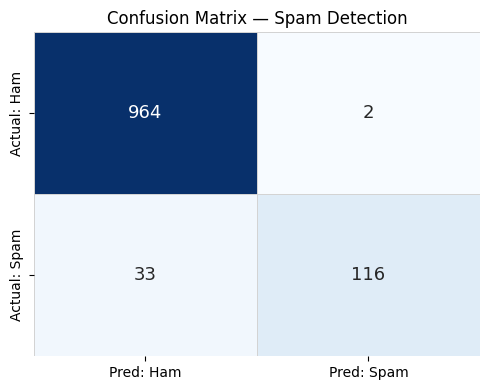

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.78      0.87       149

    accuracy                           0.97      1115
   macro avg       0.97      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [10]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Ham', 'Pred: Spam'], yticklabels=['Actual: Ham', 'Actual: Spam'],
            linewidths=0.5, linecolor='lightgray', cbar=False, annot_kws={'size': 13})
ax.set_title('Confusion Matrix — Spam Detection')
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_preds, target_names=['Ham', 'Spam']))

## class_weight

In [11]:
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_train_tfidf, y_train)
test_preds_weighted = model_weighted.predict(X_test_tfidf)

print(f'Accuracy:  {accuracy_score(y_test, test_preds_weighted):.4f}')
print(f'Precision: {precision_score(y_test, test_preds_weighted):.4f}')
print(f'Recall:    {recall_score(y_test, test_preds_weighted):.4f}')
print(f'F1:        {f1_score(y_test, test_preds_weighted):.4f}')
print(f'\nRecall: {recall_score(y_test, test_preds):.4f} -> {recall_score(y_test, test_preds_weighted):.4f}')

Accuracy:  0.9776
Precision: 0.9026
Recall:    0.9329
F1:        0.9175

Recall: 0.7785 -> 0.9329


**Observation:**
Recall can improve while Precision and accuracy move in the opposite direction, the same tradeoff seen in the imbalanced dataset notebook. For a spam filter, missing real spam is probably worse than an occasional false alarm.

## Testing on New Messages

In [12]:
test_messages = [
    "Hey, are you free to grab coffee tomorrow morning?",
    "CONGRATULATIONS! You've WON a free iPhone 15! Click the link NOW to claim your prize!!!",
    "Reminder: project submission deadline is this Friday at 5pm",
    "URGENT! Your bank account will be suspended. Verify your details immediately at this link."
]

test_cleaned = [clean_text(m) for m in test_messages]
test_tfidf = vectorizer.transform(test_cleaned)
predictions = model_weighted.predict(test_tfidf)
probabilities = model_weighted.predict_proba(test_tfidf)

for msg, pred, prob in zip(test_messages, predictions, probabilities):
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f'[{label}] P(spam)={prob[1]:.3f}  "{msg[:55]}"')

[HAM] P(spam)=0.176  "Hey, are you free to grab coffee tomorrow morning?"
[SPAM] P(spam)=0.956  "CONGRATULATIONS! You've WON a free iPhone 15! Click the"
[HAM] P(spam)=0.306  "Reminder: project submission deadline is this Friday at"
[SPAM] P(spam)=0.654  "URGENT! Your bank account will be suspended. Verify you"


**Observation:**
Hand-written examples are useful as a quick sanity check, but the real judgement should come from the held-out evaluation metrics.